In [108]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# --- the only paths to touch -------------------------------------------------
THESIS_RESULTS_DIR = "/Users/fatih/Desktop/master-thesis/thesis-results"
TABLES_DIR = os.path.join(THESIS_RESULTS_DIR, "tables")
OUTPUT_DIR = os.path.join(THESIS_RESULTS_DIR, "figures")

STEP_PROFILE_CSV = os.path.join(TABLES_DIR, "c4_step_profile_morehopqa.csv")
LOCALIZATION_CSV = os.path.join(TABLES_DIR, "c4_error_localization_morehopqa.csv")
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True,
                     "axes.spines.top": False, "axes.spines.right": False})

# The tables now carry display names in the `model` column; the old tag spelling
# is mapped on load so CSVs written before that change still work.
MODEL_LABELS = {"llama31_8b": "Llama-3.1-8B", "mistral7b_v03": "Mistral-7B",
                "Llama-3.1-8B": "Llama-3.1-8B", "Mistral-7B": "Mistral-7B"}
SIGNAL_LABELS = {"blackbox": "Black-box", "whitebox": "White-box"}

MODELS = ["Llama-3.1-8B", "Mistral-7B"]         # figure row order
SIGNALS = ["whitebox", "blackbox"]              # white-box first, everywhere

In [109]:
# Both tables are read exactly as produced by result-analysis.ipynb - this
# notebook never recomputes anything.
df_profile = pd.read_csv(STEP_PROFILE_CSV)
df_loc = pd.read_csv(LOCALIZATION_CSV)

for df in (df_profile, df_loc):
    df["model"] = df["model"].map(MODEL_LABELS)

print(f"{STEP_PROFILE_CSV} -> {len(df_profile)} rows")
print(f"{LOCALIZATION_CSV} -> {len(df_loc)} rows")
df_loc[["model", "signal", "auc", "auc_chance", "top1", "top1_chance"]]

/Users/fatih/Desktop/master-thesis/thesis-results/tables/c4_step_profile_morehopqa.csv -> 40 rows
/Users/fatih/Desktop/master-thesis/thesis-results/tables/c4_error_localization_morehopqa.csv -> 4 rows


,model,signal,auc,auc_chance,top1,top1_chance
0,Llama-3.1-8B,blackbox,0.518914,0.5,0.269682,0.215466
1,Llama-3.1-8B,whitebox,0.490089,0.5,0.201005,0.215466
2,Mistral-7B,blackbox,0.556066,0.5,0.285714,0.216531
3,Mistral-7B,whitebox,0.476417,0.5,0.197279,0.216531


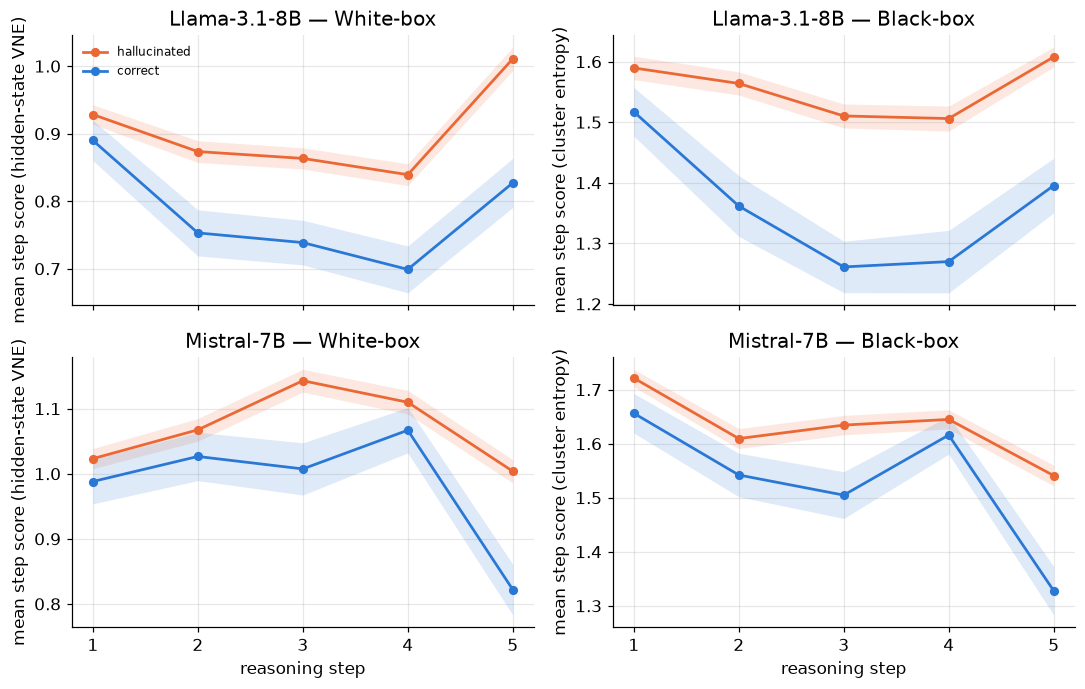

In [110]:
LABEL_COLORS = {"hallucinated": "#eb6834", "correct": "#2a78d6"}
# Black-box scores are cluster entropies, white-box scores hidden-state VNE, so
# the y-label is per column (and the axes are deliberately not shared).
YLABELS = {"blackbox": "mean step score (cluster entropy)",
           "whitebox": "mean step score (hidden-state VNE)"}

fig, axes = plt.subplots(2, 2, figsize=(10, 6.4), sharex=True, sharey=False)
for i, model in enumerate(MODELS):
    for j, signal in enumerate(SIGNALS):
        ax = axes[i, j]
        panel = df_profile[(df_profile["model"] == model) & (df_profile["signal"] == signal)]
        for label, color in LABEL_COLORS.items():
            sub = panel[panel["label"] == label].sort_values("step_index")
            x = sub["step_index"].to_numpy()
            y = sub["mean_score"].to_numpy()
            e = sub["sem_score"].to_numpy()
            ax.plot(x, y, "-o", lw=1.8, ms=5, color=color, label=label)
            ax.fill_between(x, y - e, y + e, color=color, alpha=0.15, lw=0)
        ax.set_title(f"{MODEL_LABELS[model]} — {SIGNAL_LABELS[signal]}")
        ax.set_ylabel(YLABELS[signal])
        if i == len(MODELS) - 1:
            ax.set_xlabel("reasoning step")

axes[0, 0].set_xticks([1, 2, 3, 4, 5])
axes[0, 0].legend(frameon=False, fontsize=8)
fig.tight_layout()

fig.savefig(os.path.join(OUTPUT_DIR, "c4_step_profile.png"), dpi=200, bbox_inches="tight")

plt.show()

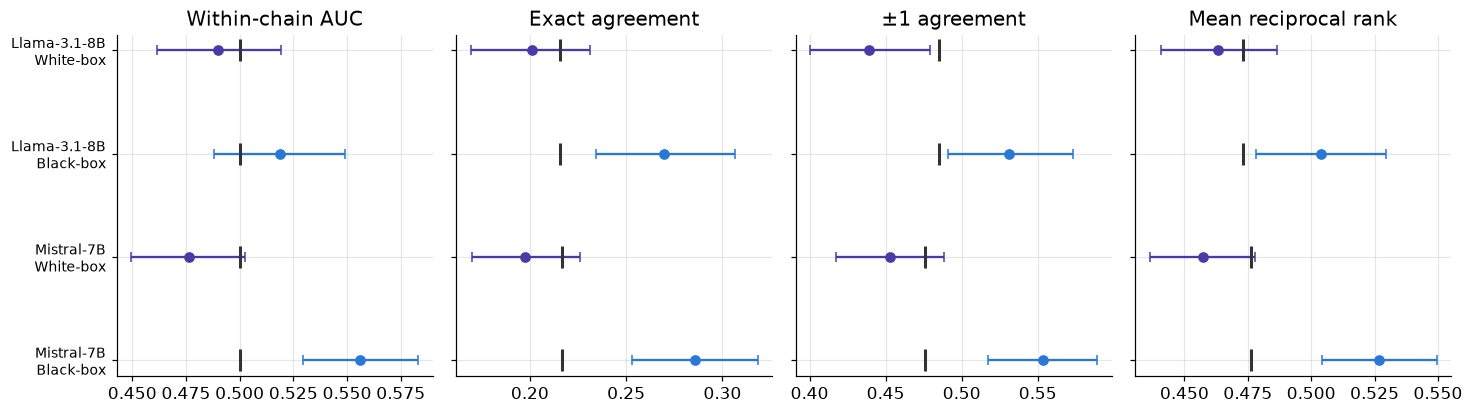

In [111]:
METRICS = [("auc", "Within-chain AUC"), ("top1", "Exact agreement"),
           ("pm1", "±1 agreement"), ("mrr", "Mean reciprocal rank")]
# Fixed top-to-bottom row order.
LOC_ROWS = [("Llama-3.1-8B", "whitebox"), ("Llama-3.1-8B", "blackbox"),
            ("Mistral-7B", "whitebox"), ("Mistral-7B", "blackbox")]
SIGNAL_COLORS = {"blackbox": "#2a78d6", "whitebox": "#4a3aa7"}

fig, axes = plt.subplots(1, len(METRICS), figsize=(13.5, 3.9))
for ax, (metric, title) in zip(axes, METRICS):
    for i, (model, signal) in enumerate(LOC_ROWS):
        r = df_loc[(df_loc["model"] == model) & (df_loc["signal"] == signal)].iloc[0]
        value, lo, hi = r[metric], r[f"{metric}_ci_lo"], r[f"{metric}_ci_hi"]
        ax.errorbar(value, i, xerr=[[value - lo], [hi - value]], fmt="o", ms=6,
                    capsize=3, lw=1.5, color=SIGNAL_COLORS[signal])
        # Chance is read per row: it depends on chain length, so it differs
        # between models for top1/pm1/mrr and is 0.5 only for auc.
        ax.plot(r[f"{metric}_chance"], i, marker="|", ms=14, mew=2, color="#333333")
    ax.set_yticks(range(len(LOC_ROWS)))
    ax.set_title(title)
    ax.invert_yaxis()

axes[0].set_yticklabels([f"{MODEL_LABELS[m]}\n{SIGNAL_LABELS[s]}" for m, s in LOC_ROWS],
                        fontsize=9)
for ax in axes[1:]:
    ax.set_yticklabels([])
fig.tight_layout()

fig.savefig(os.path.join(OUTPUT_DIR, "c4_localization_vs_chance.png"), dpi=200, bbox_inches="tight")

plt.show()

In [112]:
PAIRED_AUROC_CSV = os.path.join(TABLES_DIR, "paired_delta_auroc.csv")
PAIRED_PRR_CSV = os.path.join(TABLES_DIR, "paired_delta_prr.csv")

DATASET_LABELS = {"triviaqa": "TriviaQA", "nqopen": "NQ-Open", "morehopqa": "MoreHopQA"}
ALPHA = 0.05                      # significance threshold on p_two_sided

# Row order shared by both cross-signal figures.
FIG_MODELS = ["Llama-3.1-8B", "Mistral-7B"]
FIG_DATASETS = ["triviaqa", "nqopen", "morehopqa"]
FIG_CONDITIONS = ["C1", "C2", "C3", "C4 (max)"]


def load_cross_signal(path):
    """The white-box minus black-box rows of a paired-delta table.

    Delta is white-box minus black-box, so positive means the white-box signal
    detects better. `condition` merges method_a with its variant (only C4 has
    one, `max`). Model names are normalised because tables written before the
    display-name change carry the old tag spelling.
    """
    df = pd.read_csv(path)
    df = df[df["signal"] == "cross_signal"].copy()
    df["model"] = df["model"].map(MODEL_LABELS)
    df["condition"] = [f"{m} ({v})" if isinstance(v, str) else m
                       for m, v in zip(df["method_a"], df["variant_a"])]
    df["significant"] = df["p_two_sided"] < ALPHA
    return df.set_index(["model", "dataset", "condition"])


cs_auroc = load_cross_signal(PAIRED_AUROC_CSV)
cs_prr = load_cross_signal(PAIRED_PRR_CSV)

for name, df in [("AUROC", cs_auroc), ("PRR", cs_prr)]:
    print(f"{name:5s}: {len(df):2d} rows | significant {int(df['significant'].sum()):2d}"
          f" | delta min {df['delta'].min():+.3f} max {df['delta'].max():+.3f}")
print("conditions:", sorted(cs_auroc.index.get_level_values('condition').unique()))

AUROC: 24 rows | significant 15 | delta min -0.147 max +0.107
PRR  : 24 rows | significant 12 | delta min -0.271 max +0.281
conditions: ['C1', 'C2', 'C3', 'C4 (max)']


Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/fig_6_4_cross_signal_forest.png


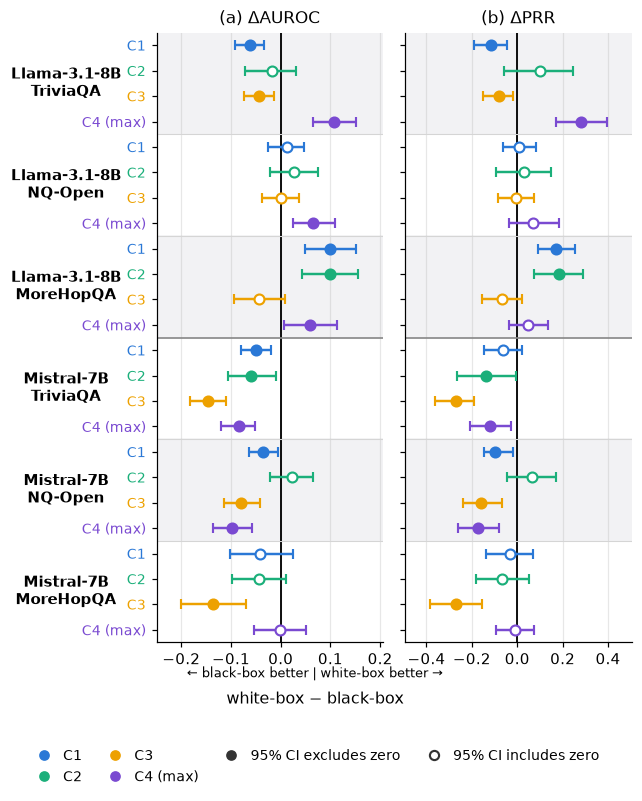

In [113]:
FOREST_ROWS = [(model, dataset, cond) for model in FIG_MODELS
               for dataset in FIG_DATASETS for cond in FIG_CONDITIONS]
COND_COLORS = {"C1": "#2a78d6", "C2": "#1baf7a", "C3": "#eda100", "C4 (max)": "#7a4ad1"}
BLOCK_SHADE = "#f2f2f4"           # every other model x dataset block


def ci_excludes_zero(row):
    """Significance criterion of this figure: the paired 95% bootstrap interval
    lies entirely on one side of zero. (Equivalent to the stored percentile
    p-value by construction, verified identical on all rows.)"""
    return bool(row["ci_lo"] > 0 or row["ci_hi"] < 0)


def plot_cross_signal_forest():
    with plt.rc_context({"font.size": 9.5}):
        fig, axes = plt.subplots(1, 2, figsize=(7.2, 7.2), sharey=True)
        n_block = len(FIG_CONDITIONS)
        n_rows = len(FOREST_ROWS)

        for ax, (df, title) in zip(axes, [(cs_auroc, "(a) $\\Delta$AUROC"),
                                          (cs_prr, "(b) $\\Delta$PRR")]):
            # Alternating block shading carries the grouping even in greyscale.
            for b in range(0, n_rows // n_block, 2):
                ax.axhspan(b * n_block - 0.5, (b + 1) * n_block - 0.5,
                           color=BLOCK_SHADE, zorder=0)
            for i, key in enumerate(FOREST_ROWS):
                r = df.loc[key]
                color = COND_COLORS[key[2]]
                ax.errorbar(r["delta"], i,
                            xerr=[[r["delta"] - r["ci_lo"]], [r["ci_hi"] - r["delta"]]],
                            fmt="o", ms=6.5, capsize=3, lw=1.6, color=color, zorder=3,
                            markerfacecolor=color if ci_excludes_zero(r) else "white",
                            markeredgewidth=1.4)
            ax.axvline(0, color="black", lw=1.2, zorder=2)
            for b in range(1, n_rows // n_block):
                # Thicker rule where the model changes, hairline between datasets.
                is_model_break = b == (n_rows // n_block) // 2
                ax.axhline(b * n_block - 0.5, color="#888888" if is_model_break else "#d5d5d5",
                           lw=1.1 if is_model_break else 0.7, zorder=2)
            ax.set_title(title, fontsize=11)
            ax.margins(x=0.14)
            ax.grid(axis="x", alpha=0.3)
            ax.grid(axis="y", visible=False)

        axes[0].set_yticks(range(n_rows))
        axes[0].set_yticklabels([c for _, _, c in FOREST_ROWS], fontsize=9)
        for tick, (_, _, cond) in zip(axes[0].get_yticklabels(), FOREST_ROWS):
            tick.set_color(COND_COLORS[cond])
        axes[0].set_ylim(n_rows - 0.5, -0.5)               # first row on top

        for b, (model, dataset) in enumerate([(m, d) for m in FIG_MODELS for d in FIG_DATASETS]):
            centre = b * n_block + (n_block - 1) / 2
            axes[0].text(-0.40, centre, f"{model}\n{DATASET_LABELS[dataset]}",
                         transform=axes[0].get_yaxis_transform(), ha="center", va="center",
                         fontsize=9.5, fontweight="bold")

        # Direction annotation sits centred under BOTH panels: the contrast is
        # white-box minus black-box in either metric.
        fig.supxlabel("white-box − black-box", fontsize=10.5, y=0.028)
        fig.text(0.5, 0.062, "← black-box better | white-box better →",
                 ha="center", va="bottom", fontsize=8.5)

        handles = [Line2D([0], [0], marker="o", ls="none", color=COND_COLORS[c],
                          markerfacecolor=COND_COLORS[c], label=c) for c in FIG_CONDITIONS]
        handles += [Line2D([0], [0], marker="o", ls="none", color="#333333",
                           markerfacecolor="#333333", label="95% CI excludes zero"),
                    Line2D([0], [0], marker="o", ls="none", color="#333333",
                           markerfacecolor="white", markeredgewidth=1.4,
                           label="95% CI includes zero")]
        # Two centred rows: conditions on the first, interval readings on the second.
        fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.085),
                   ncol=4, fontsize=9, frameon=False, columnspacing=1.4, handletextpad=0.4)
        fig.subplots_adjust(left=0.30, bottom=0.11, wspace=0.10)

        stem = os.path.join(OUTPUT_DIR, "fig_6_4_cross_signal_forest")
        fig.savefig(f"{stem}.png", dpi=300, bbox_inches="tight")
        print(f"Saved -> {stem}.png")
        plt.show()


plot_cross_signal_forest()

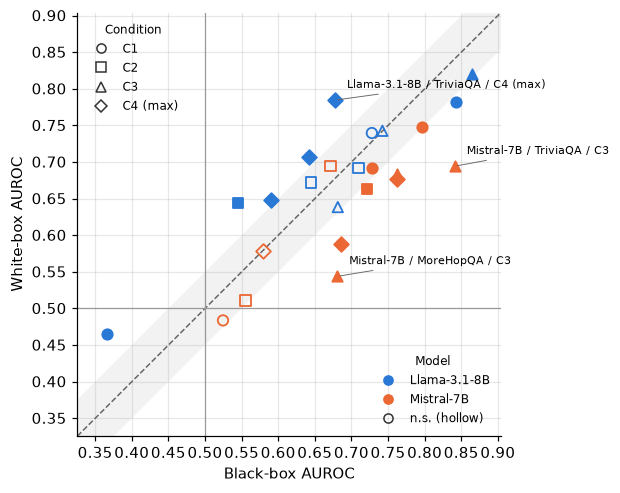

In [114]:
from matplotlib.ticker import MultipleLocator

COND_MARKERS = {"C1": "o", "C2": "s", "C3": "^", "C4 (max)": "D"}
MODEL_COLORS = {"Llama-3.1-8B": "#2a78d6", "Mistral-7B": "#eb6834"}
BAND = 0.05                       # "comparable" corridor around the identity line


def plot_signal_scatter():
    with plt.rc_context({"font.size": 9.5}):
        fig, ax = plt.subplots(figsize=(5, 5))
        pts = cs_auroc.reset_index()
        lo = min(pts["auroc_a"].min(), pts["auroc_b"].min()) - 0.04
        hi = max(pts["auroc_a"].max(), pts["auroc_b"].max()) + 0.04

        ax.fill_between([lo, hi], [lo - BAND, hi - BAND], [lo + BAND, hi + BAND],
                        color="#bbbbbb", alpha=0.18, lw=0, zorder=0)
        ax.plot([lo, hi], [lo, hi], ls="--", lw=1, color="#666666", zorder=1)
        ax.axvline(0.5, color="#999999", lw=0.8, zorder=1)
        ax.axhline(0.5, color="#999999", lw=0.8, zorder=1)

        for _, r in pts.iterrows():
            color = MODEL_COLORS[r["model"]]
            ax.scatter(r["auroc_b"], r["auroc_a"], marker=COND_MARKERS[r["condition"]], s=46,
                       facecolor=color if r["significant"] else "none", edgecolor=color,
                       linewidth=1.2, zorder=3)

        # Callouts for the three largest movements only.
        for _, r in pts.reindex(pts["delta"].abs().sort_values(ascending=False).index).head(3).iterrows():
            ax.annotate(f"{r['model']} / {DATASET_LABELS[r['dataset']]} / {r['condition']}",
                        (r["auroc_b"], r["auroc_a"]), textcoords="offset points",
                        xytext=(8, 8), fontsize=7.5,
                        arrowprops=dict(arrowstyle="-", lw=0.6, color="#666666"))

        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal")
        ax.xaxis.set_major_locator(MultipleLocator(0.05))
        ax.yaxis.set_major_locator(MultipleLocator(0.05))
        ax.grid(True)
        ax.set_xlabel("Black-box AUROC")
        ax.set_ylabel("White-box AUROC")

        cond_handles = [Line2D([0], [0], marker=COND_MARKERS[c], ls="none", color="#333333",
                               markerfacecolor="none", label=c) for c in FIG_CONDITIONS]
        model_handles = [Line2D([0], [0], marker="o", ls="none", color=MODEL_COLORS[m],
                                markerfacecolor=MODEL_COLORS[m], label=m) for m in FIG_MODELS]
        model_handles.append(Line2D([0], [0], marker="o", ls="none", color="#333333",
                                    markerfacecolor="none", label="n.s. (hollow)"))
        cond_legend = ax.legend(handles=cond_handles, title="Condition", loc="upper left",
                                fontsize=8, title_fontsize=8, frameon=False)
        ax.add_artist(cond_legend)
        ax.legend(handles=model_handles, title="Model", loc="lower right",
                  fontsize=8, title_fontsize=8, frameon=False)

        stem = os.path.join(OUTPUT_DIR, "fig_6_5_signal_scatter")
        fig.savefig(f"{stem}.png", dpi=300, bbox_inches="tight")

        plt.show()


plot_signal_scatter()

In [115]:
BASELINE_CMP_CSV = os.path.join(TABLES_DIR, "baseline_comparison_auroc.csv")

BASELINE_ORDER = {"blackbox": ["SelfCheckGPT-NLI", "SE (discrete)"],
                  "whitebox": ["LLM-Check", "SE (weighted)"]}
KLE_ORDER = ["C2", "C3", "C4 (max)"]
SERIES_ORDER = {sg: KLE_ORDER + BASELINE_ORDER[sg] for sg in SIGNALS}
BASELINE_METHODS = ["SemanticEntropy", "SelfCheckGPT-NLI", "LLM-Check"]


def series_label(method, variant):
    """Display name for a (method, variant) pair; variant is NaN where unused."""
    if not isinstance(variant, str):
        return method
    if method == "LLM-Check":
        return "LLM-Check"                       # only logit_entropy is plotted
    if method == "SemanticEntropy":
        return f"SE ({variant.replace('se_', '')})"
    return f"{method} ({variant})"


def normalise(df):
    """Display names for the model column, plus a dataset label where the table
    has a dataset column (the correlations table does not)."""
    df = df.copy()
    df["model"] = df["model"].map(MODEL_LABELS)
    if "dataset" in df.columns:
        df["dataset_label"] = df["dataset"].map(DATASET_LABELS)
    return df


# --- Figure 1 source: one AUROC per (model, dataset, signal, series) ----------
bl = normalise(pd.read_csv(BASELINE_CMP_CSV))
bl = bl[bl["in_figure"]].copy()
bl["series"] = [series_label(m, v) for m, v in zip(bl["method"], bl["variant"])]
# Only the max aggregation of C4, so the figure matches the thesis tables.
bl = bl[(bl["family"] == "baseline") | bl["series"].isin(KLE_ORDER)]
bl = bl.set_index(["model", "dataset", "signal", "series"])

# --- Figure 2 source: paired contrasts of a condition against a baseline -----
pd_base = normalise(pd.read_csv(PAIRED_AUROC_CSV))
pd_base = pd_base[pd_base["method_b"].isin(BASELINE_METHODS)].copy()
assert len(pd_base) == 72, f"expected 72 condition-vs-baseline contrasts, got {len(pd_base)}"
pd_base["condition"] = [series_label(m, v) for m, v in zip(pd_base["method_a"], pd_base["variant_a"])]
pd_base["baseline"] = [series_label(m, v) for m, v in zip(pd_base["method_b"], pd_base["variant_b"])]
pd_base["significant"] = pd_base["p_two_sided"] < ALPHA
assert set(pd_base["condition"]) == set(KLE_ORDER), sorted(set(pd_base["condition"]))
print(f"condition-vs-baseline contrasts: {len(pd_base)} rows")

for sg in SIGNALS:
    fig1 = bl.xs(sg, level="signal")
    fig2 = pd_base[pd_base["signal"] == sg]
    print(f"{SIGNAL_LABELS[sg]:10s} | bars {len(fig1):2d} | contrasts {len(fig2):2d}"
          f" | significant {int(fig2['significant'].sum()):2d}"
          f" | delta min {fig2['delta'].min():+.3f} max {fig2['delta'].max():+.3f}")
print("same-generations contrasts:", int(pd_base["same_generations"].sum()))

condition-vs-baseline contrasts: 72 rows
White-box  | bars 30 | contrasts 36 | significant 20 | delta min -0.070 max +0.161
Black-box  | bars 30 | contrasts 36 | significant 26 | delta min -0.115 max +0.206
same-generations contrasts: 18


Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/fig_6_6_baseline_grouped_bars.png


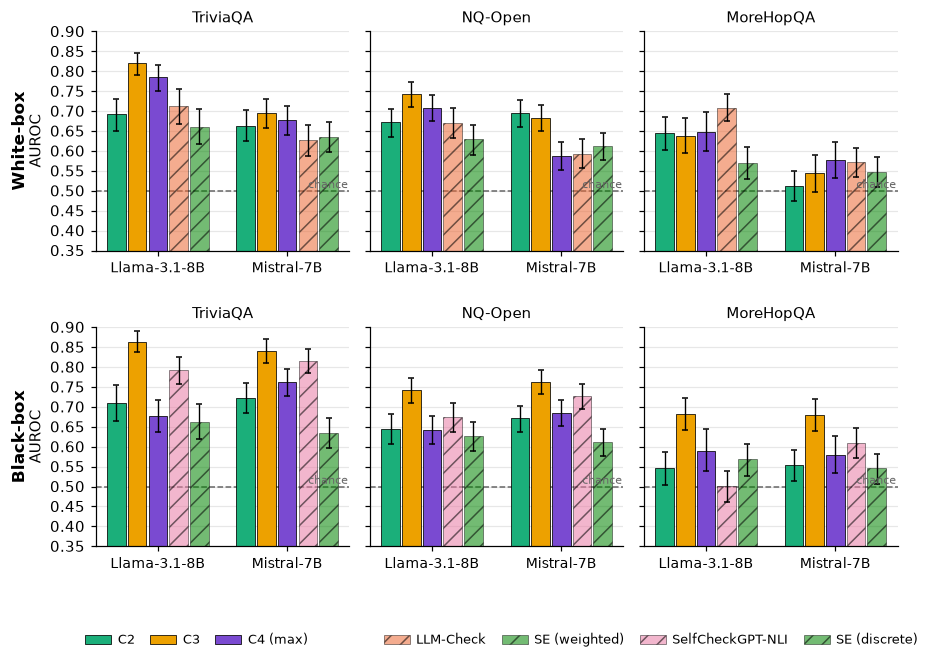

In [116]:
SERIES_COLORS = {"C2": "#1baf7a", "C3": "#eda100", "C4 (max)": "#7a4ad1",
                 "SelfCheckGPT-NLI": "#e87ba4", "SE (discrete)": "#008300",
                 "LLM-Check": "#eb6834", "SE (weighted)": "#008300"}
BASELINE_HATCH = "//"


def plot_baseline_grouped_bars():
    with plt.rc_context({"font.size": 9.5}):
        fig, axes = plt.subplots(2, len(FIG_DATASETS), figsize=(9, 6), sharey=True)
        for i, signal in enumerate(SIGNALS):
            series = SERIES_ORDER[signal]
            w = 0.8 / len(series)
            for j, dataset in enumerate(FIG_DATASETS):
                ax = axes[i, j]
                for k, name in enumerate(series):
                    xs, ys, lo, hi = [], [], [], []
                    for g, model in enumerate(FIG_MODELS):
                        r = bl.loc[(model, dataset, signal, name)]
                        xs.append(g + (k - (len(series) - 1) / 2) * w)
                        ys.append(r["auroc"])
                        lo.append(r["auroc"] - r["ci_lo"])
                        hi.append(r["ci_hi"] - r["auroc"])
                    is_baseline = name not in KLE_ORDER
                    ax.bar(xs, ys, width=w * 0.9, color=SERIES_COLORS[name],
                           alpha=0.55 if is_baseline else 1.0,
                           hatch=BASELINE_HATCH if is_baseline else "",
                           edgecolor="black", linewidth=0.5, zorder=2)
                    ax.errorbar(xs, ys, yerr=[lo, hi], fmt="none", ecolor="black",
                                elinewidth=0.9, capsize=2, zorder=3)
                ax.axhline(0.5, ls="--", lw=1, color="#666666", zorder=1)
                ax.text(0.995, 0.5, "chance", transform=ax.get_yaxis_transform(),
                        ha="right", va="bottom", fontsize=7.5, color="#666666")
                ax.set_xticks(range(len(FIG_MODELS)))
                ax.set_xticklabels(FIG_MODELS, fontsize=9)
                ax.set_title(DATASET_LABELS[dataset], fontsize=10)
                ax.set_ylim(0.35, 0.90)
                ax.set_yticks(np.arange(0.35, 0.901, 0.05))
                ax.grid(axis="y", alpha=0.3)
                ax.grid(axis="x", visible=False)
            axes[i, 0].set_ylabel("AUROC")
            axes[i, 0].text(-0.30, 0.5, SIGNAL_LABELS[signal], transform=axes[i, 0].transAxes,
                            rotation=90, ha="center", va="center", fontsize=11, fontweight="bold")

        # Legend: thesis conditions first, then a gap, then the baselines of both signals.
        def patch(name):
            is_baseline = name not in KLE_ORDER
            return Patch(facecolor=SERIES_COLORS[name], edgecolor="black", linewidth=0.5,
                         alpha=0.55 if is_baseline else 1.0,
                         hatch=BASELINE_HATCH if is_baseline else "", label=name)

        handles = [patch(n) for n in KLE_ORDER]
        handles.append(Patch(facecolor="none", edgecolor="none", label="   "))
        handles += [patch(n) for sg in SIGNALS for n in BASELINE_ORDER[sg]]
        fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.07),
                   ncol=len(handles), fontsize=8.5, frameon=False, columnspacing=1.2,
                   handletextpad=0.5)
        fig.subplots_adjust(left=0.09, bottom=0.10, hspace=0.35, wspace=0.08)

        stem = os.path.join(OUTPUT_DIR, "fig_6_6_baseline_grouped_bars")
        fig.savefig(f"{stem}.png", dpi=300, bbox_inches="tight")
        print(f"Saved -> {stem}.png")
        plt.show()


plot_baseline_grouped_bars()

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/fig_6_7_baseline_paired_forest.png


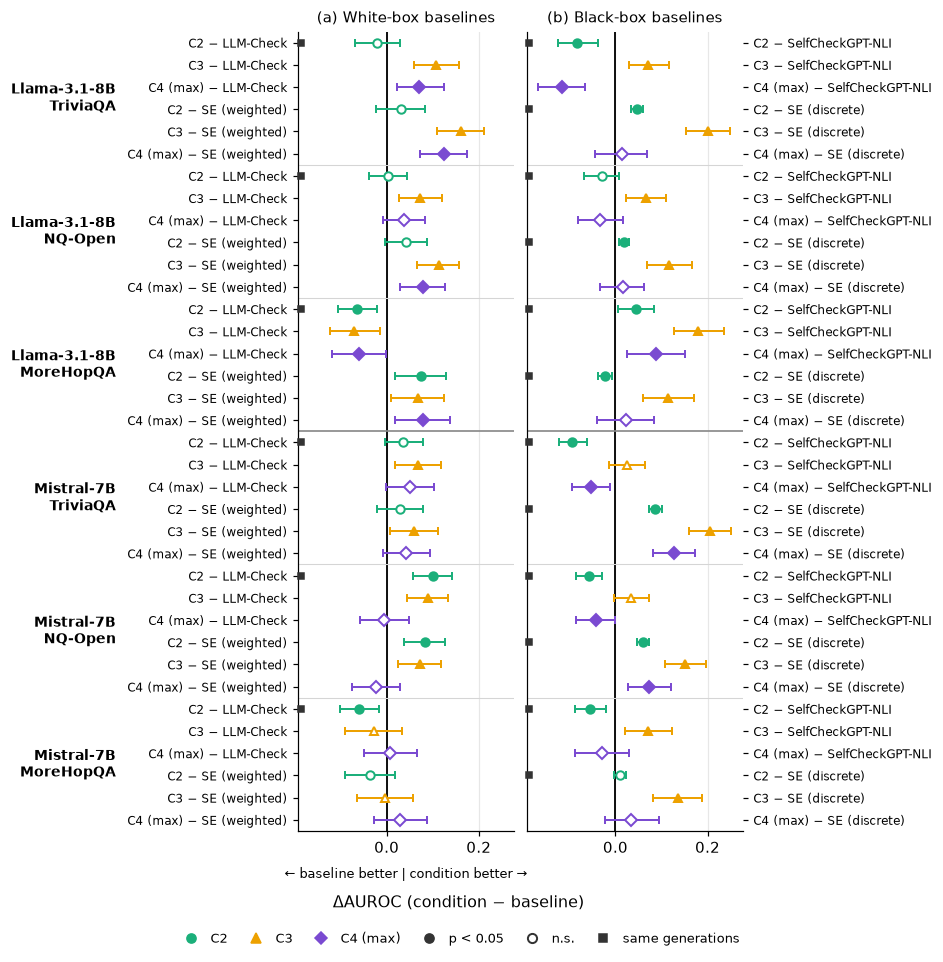

In [117]:
COND_MARKERS_B = {"C2": "o", "C3": "^", "C4 (max)": "D"}
COND_COLORS_B = {"C2": "#1baf7a", "C3": "#eda100", "C4 (max)": "#7a4ad1"}


def contrast_rows(signal):
    """(model, dataset, baseline, condition) rows in plotting order, top first."""
    return [(m, d, b, c) for m in FIG_MODELS for d in FIG_DATASETS
            for b in BASELINE_ORDER[signal] for c in KLE_ORDER]


def plot_baseline_paired_forest():
    with plt.rc_context({"font.size": 9.5}):
        # NOT sharey: the two panels carry different baseline names on their ticks,
        # and a shared y axis makes the second set_yticklabels overwrite the first.
        # The limits are set identically by hand instead.
        fig, axes = plt.subplots(1, 2, figsize=(8.6, 9.2))
        idx = pd_base.set_index(["signal", "model", "dataset", "baseline", "condition"])
        n_block = len(KLE_ORDER) * 2                      # two baselines per model x dataset
        rows_per_panel = {sg: contrast_rows(sg) for sg in SIGNALS}
        n_rows = len(rows_per_panel["blackbox"])

        span = [min(idx["ci_lo"]), max(idx["ci_hi"])]
        pad = 0.06 * (span[1] - span[0])

        panel_titles = [f"({letter}) {SIGNAL_LABELS[sg]} baselines"
                        for letter, sg in zip("ab", SIGNALS)]
        for ax, signal, title in zip(axes, SIGNALS, panel_titles):
            for i, (model, dataset, baseline, cond) in enumerate(rows_per_panel[signal]):
                r = idx.loc[(signal, model, dataset, baseline, cond)]
                color = COND_COLORS_B[cond]
                ax.errorbar(r["delta"], i,
                            xerr=[[r["delta"] - r["ci_lo"]], [r["ci_hi"] - r["delta"]]],
                            fmt=COND_MARKERS_B[cond], ms=5.5, capsize=2.5, lw=1.3, color=color,
                            markerfacecolor=color if r["significant"] else "white",
                            markeredgewidth=1.3, zorder=3)
                if r["same_generations"]:
                    # Strictly like-for-like: identical generations and labels.
                    ax.plot(0.012, i, marker="s", ms=4, color="#333333", clip_on=False,
                            transform=ax.get_yaxis_transform(), zorder=4)
            ax.axvline(0, color="black", lw=1.2, zorder=2)
            for b in range(1, n_rows // n_block):
                is_model_break = b == (n_rows // n_block) // 2
                ax.axhline(b * n_block - 0.5, color="#888888" if is_model_break else "#d5d5d5",
                           lw=1.1 if is_model_break else 0.7, zorder=2)
            ax.set_yticks(range(n_rows))
            ax.set_yticklabels([f"{c} − {b}" for _, _, b, c in rows_per_panel[signal]], fontsize=7.8)
            if signal == SIGNALS[1]:
                ax.yaxis.tick_right()                    # outward, so it cannot cover panel (a)
            ax.set_ylim(n_rows - 0.5, -0.5)              # identical limits, first row on top
            ax.set_xlim(span[0] - pad, span[1] + pad)    # shared scale => comparable effect sizes
            ax.set_title(title, fontsize=10)
            ax.grid(axis="x", alpha=0.3)
            ax.grid(axis="y", visible=False)

        fig.subplots_adjust(left=0.33, right=0.80, bottom=0.09, wspace=0.06)

        # Block labels go just left of the tick labels. Their width depends on the
        # rendered text, so measure it instead of guessing an offset.
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()
        left_px = min(t.get_window_extent(renderer).x0 for t in axes[0].get_yticklabels())
        left_fig = fig.transFigure.inverted().transform((left_px, 0))[0] - 0.012
        for b, (model, dataset) in enumerate([(m, d) for m in FIG_MODELS for d in FIG_DATASETS]):
            centre = b * n_block + (n_block - 1) / 2
            y_px = axes[0].get_yaxis_transform().transform((0, centre))[1]
            y_fig = fig.transFigure.inverted().transform((0, y_px))[1]
            fig.text(left_fig, y_fig, f"{model}\n{DATASET_LABELS[dataset]}",
                     ha="right", va="center", fontsize=9, fontweight="bold")

        fig.supxlabel("$\\Delta$AUROC (condition − baseline)", fontsize=10.5)
        axes[0].text(0.5, -0.045, "← baseline better | condition better →",
                     transform=axes[0].transAxes, ha="center", va="top", fontsize=8.5)

        handles = [Line2D([0], [0], marker=COND_MARKERS_B[c], ls="none", color=COND_COLORS_B[c],
                          markerfacecolor=COND_COLORS_B[c], label=c) for c in KLE_ORDER]
        handles += [Line2D([0], [0], marker="o", ls="none", color="#333333",
                           markerfacecolor="#333333", label=f"p < {ALPHA:g}"),
                    Line2D([0], [0], marker="o", ls="none", color="#333333",
                           markerfacecolor="white", markeredgewidth=1.3, label="n.s."),
                    Line2D([0], [0], marker="s", ls="none", color="#333333", ms=5,
                           label="same generations")]
        fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.035),
                   ncol=6, fontsize=8.5, frameon=False, columnspacing=1.2, handletextpad=0.5)
        stem = os.path.join(OUTPUT_DIR, "fig_6_7_baseline_paired_forest")
        fig.savefig(f"{stem}.png", dpi=300, bbox_inches="tight")
        print(f"Saved -> {stem}.png")
        plt.show()


plot_baseline_paired_forest()

In [118]:
HR_AUROC_CSV = os.path.join(TABLES_DIR, "hallucination_rate_vs_auroc.csv")
HR_CORR_CSV = os.path.join(TABLES_DIR, "hallucination_rate_vs_auroc_correlations.csv")
TOKEN_COST_CSV = os.path.join(TABLES_DIR, "token_cost.csv")

FIG_CONDITIONS_PLAIN = ["C1", "C2", "C3", "C4"]     # aggregation name is not shown here

hr = normalise(pd.read_csv(HR_AUROC_CSV))
hr_corr = normalise(pd.read_csv(HR_CORR_CSV))       # printed only, never plotted
tok = normalise(pd.read_csv(TOKEN_COST_CSV))

hr = hr.set_index(["model", "signal", "dataset", "condition"])
tok = tok.set_index(["model", "dataset", "signal", "condition"])

print("Figure 1 — hallucination rate vs AUROC")
for model in FIG_MODELS:
    for signal in SIGNALS:
        panel = hr.xs((model, signal), level=("model", "signal"))
        rho = hr_corr[(hr_corr["model"] == model) & (hr_corr["signal"] == signal)
                      & (hr_corr["scope"] == "overall")]["spearman_rho"].iloc[0]
        print(f"  {model:13s} {SIGNAL_LABELS[signal]:10s} | {len(panel):2d} points"
              f" | rate {panel['hallucination_rate'].min():.3f}-{panel['hallucination_rate'].max():.3f}"
              f" | AUROC {panel['auroc'].min():.3f}-{panel['auroc'].max():.3f}"
              f" | stored overall Spearman rho {rho:+.3f}")

print("\nFigure 2 — token cost")
for model in FIG_MODELS:
    for dataset in FIG_DATASETS:
        panel = tok.xs((model, dataset), level=("model", "dataset"))
        print(f"  {model:13s} {DATASET_LABELS[dataset]:10s} | {len(panel)} bars")
totals = tok["mean_total_tokens"]
for name, key in [("largest", totals.idxmax()), ("smallest", totals.idxmin())]:
    m, d, sg, c = key
    print(f"  {name:8s} bar: {totals[key]:>9,.0f} tokens/question"
          f"  ({m}, {DATASET_LABELS[d]}, {SIGNAL_LABELS[sg]}, {c})")

Figure 1 — hallucination rate vs AUROC
  Llama-3.1-8B  White-box  | 12 points | rate 0.189-0.846 | AUROC 0.465-0.821 | stored overall Spearman rho -0.720
  Llama-3.1-8B  Black-box  | 12 points | rate 0.190-0.846 | AUROC 0.366-0.864 | stored overall Spearman rho -0.713
  Mistral-7B    White-box  | 12 points | rate 0.261-0.827 | AUROC 0.484-0.747 | stored overall Spearman rho -0.724
  Mistral-7B    Black-box  | 12 points | rate 0.259-0.827 | AUROC 0.525-0.841 | stored overall Spearman rho -0.762

Figure 2 — token cost
  Llama-3.1-8B  TriviaQA   | 8 bars
  Llama-3.1-8B  NQ-Open    | 8 bars
  Llama-3.1-8B  MoreHopQA  | 8 bars
  Mistral-7B    TriviaQA   | 8 bars
  Mistral-7B    NQ-Open    | 8 bars
  Mistral-7B    MoreHopQA  | 8 bars
  largest  bar:    15,573 tokens/question  (Mistral-7B, MoreHopQA, White-box, C4)
  smallest bar:       261 tokens/question  (Mistral-7B, TriviaQA, Black-box, C1)


Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/fig_6_8_rate_vs_auroc.png


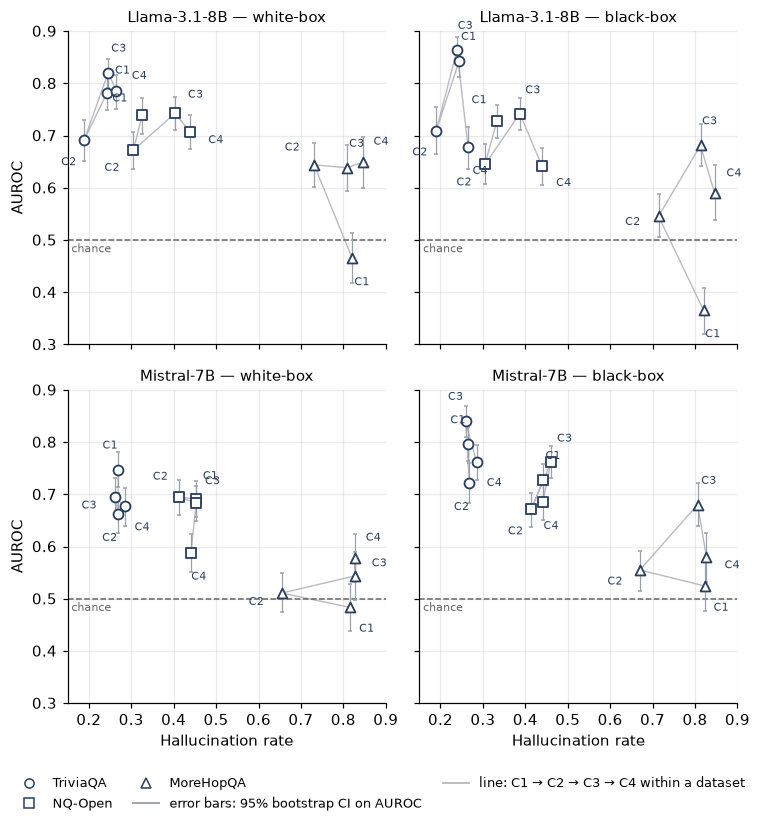

In [119]:
from matplotlib.ticker import MultipleLocator

DATASET_MARKERS_8 = {"triviaqa": "o", "nqopen": "s", "morehopqa": "^"}
TRAJECTORY_COLOR = "#b9b9c2"
ERRORBAR_COLOR = "#9aa0ab"
POINT_COLOR = "#2a3f5f"
XLIM_8, YLIM_8 = (0.15, 0.90), (0.30, 0.90)
LABEL_PAD = 12                      # points, distance of the condition label from its marker


def label_offset(x, y, cx, cy):
    """Push a condition label radially away from its dataset's centroid.

    Manual per-condition nudges do not survive tightly packed clusters (TriviaQA);
    fanning the four labels outwards keeps them clear of the markers and of each
    other. Returns the offset in points plus matching text alignment.
    """
    dx = (x - cx) / (XLIM_8[1] - XLIM_8[0])
    dy = (y - cy) / (YLIM_8[1] - YLIM_8[0])
    norm = (dx ** 2 + dy ** 2) ** 0.5
    if norm < 1e-9:                 # point sits on the centroid: fall back to up-right
        dx, dy, norm = 0.7, 0.7, 1.0
    ox, oy = LABEL_PAD * dx / norm, LABEL_PAD * dy / norm
    return (ox, oy), ("left" if ox >= 0 else "right"), ("bottom" if oy >= 0 else "top")


def plot_rate_vs_auroc():
    with plt.rc_context({"font.size": 9.5}):
        fig, axes = plt.subplots(2, 2, figsize=(7, 7), sharex=True, sharey=True)
        for i, model in enumerate(FIG_MODELS):
            for j, signal in enumerate(SIGNALS):
                ax = axes[i, j]
                for dataset in FIG_DATASETS:
                    rows = [hr.loc[(model, signal, dataset, c)] for c in FIG_CONDITIONS_PLAIN]
                    xs = [r["hallucination_rate"] for r in rows]
                    ys = [r["auroc"] for r in rows]
                    # Reading aid: the within-dataset trajectory C1 -> C2 -> C3 -> C4.
                    ax.plot(xs, ys, "-", lw=0.9, color=TRAJECTORY_COLOR, zorder=1)
                    ax.errorbar(xs, ys,
                                yerr=[[r["auroc"] - r["auroc_ci_lo"] for r in rows],
                                      [r["auroc_ci_hi"] - r["auroc"] for r in rows]],
                                fmt="none", ecolor=ERRORBAR_COLOR, elinewidth=0.8,
                                capsize=1.5, zorder=2)
                    ax.scatter(xs, ys, marker=DATASET_MARKERS_8[dataset], s=42,
                               facecolor="white", edgecolor=POINT_COLOR, linewidth=1.2, zorder=3)
                    for k, (cond, x, y) in enumerate(zip(FIG_CONDITIONS_PLAIN, xs, ys)):
                        # Reference = the other three points, so labels of a tight
                        # cluster fan out instead of stacking on one another.
                        others_x = [v for m, v in enumerate(xs) if m != k]
                        others_y = [v for m, v in enumerate(ys) if m != k]
                        offset, ha, va = label_offset(
                            x, y, sum(others_x) / len(others_x), sum(others_y) / len(others_y))
                        ax.annotate(cond, (x, y), textcoords="offset points", xytext=offset,
                                    ha=ha, va=va, fontsize=7.5, color=POINT_COLOR, zorder=4)
                ax.axhline(0.5, ls="--", lw=1, color="#666666", zorder=1)
                # Bottom-left corner: below the line, and empty in every panel
                # (the low-rate cells all sit well above 0.5).
                ax.text(0.012, 0.494, "chance", transform=ax.get_yaxis_transform(),
                        ha="left", va="top", fontsize=7, color="#666666")
                ax.set_xlim(*XLIM_8)
                ax.set_ylim(*YLIM_8)
                ax.xaxis.set_major_locator(MultipleLocator(0.1))
                ax.yaxis.set_major_locator(MultipleLocator(0.1))
                ax.grid(alpha=0.25)
                ax.set_title(f"{model} — {SIGNAL_LABELS[signal].lower()}", fontsize=10)
                if i == len(FIG_MODELS) - 1:
                    ax.set_xlabel("Hallucination rate")
                if j == 0:
                    ax.set_ylabel("AUROC")

        handles = [Line2D([0], [0], marker=DATASET_MARKERS_8[d], ls="none", color=POINT_COLOR,
                          markerfacecolor="white", label=DATASET_LABELS[d]) for d in FIG_DATASETS]
        handles += [Line2D([0], [0], color=ERRORBAR_COLOR, lw=1.2,
                           label="error bars: 95% bootstrap CI on AUROC"),
                    Line2D([0], [0], color=TRAJECTORY_COLOR, lw=1.2,
                           label="line: C1 → C2 → C3 → C4 within a dataset")]
        fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.075),
                   ncol=3, fontsize=8.5, frameon=False, columnspacing=1.6)
        fig.tight_layout()

        stem = os.path.join(OUTPUT_DIR, "fig_6_8_rate_vs_auroc")
        fig.savefig(f"{stem}.png", dpi=300, bbox_inches="tight")
        print(f"Saved -> {stem}.png")
        plt.show()


plot_rate_vs_auroc()

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/fig_6_9_token_cost.png


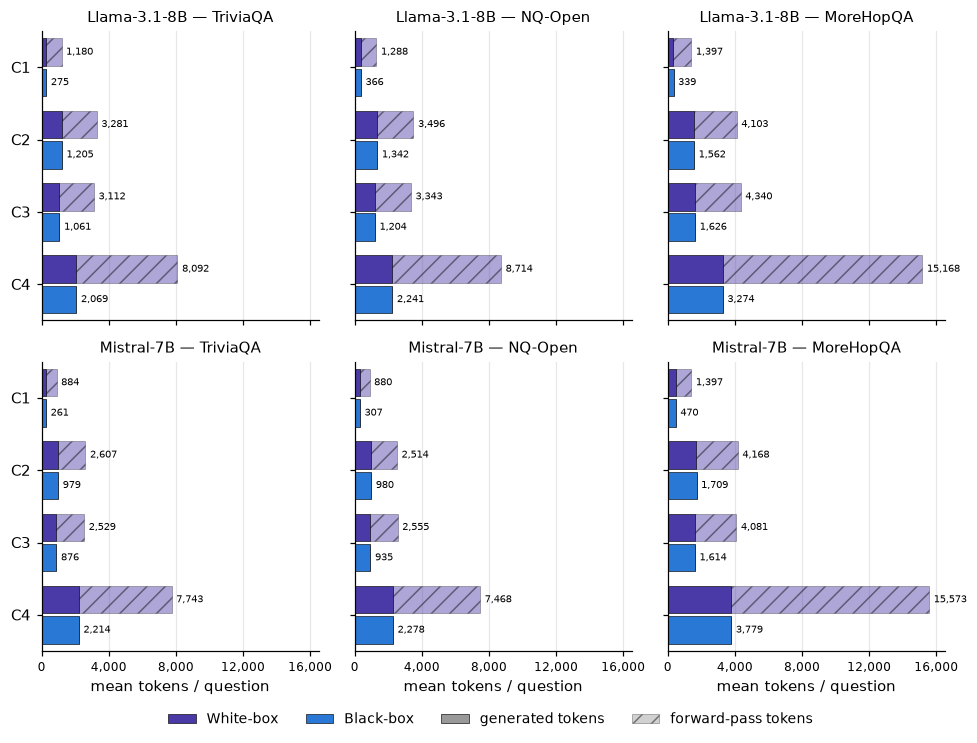

In [120]:
TOKEN_SIGNAL_COLORS = {"whitebox": "#4a3aa7", "blackbox": "#2a78d6"}
TOKEN_XMAX = 16500                  # C4 white-box sets the scale for every panel


def plot_token_cost():
    with plt.rc_context({"font.size": 9.5}):
        fig, axes = plt.subplots(len(FIG_MODELS), len(FIG_DATASETS), figsize=(9, 6.5),
                                 sharex=True, sharey=True)
        for i, model in enumerate(FIG_MODELS):
            for j, dataset in enumerate(FIG_DATASETS):
                ax = axes[i, j]
                for k, cond in enumerate(FIG_CONDITIONS_PLAIN):
                    for s, signal in enumerate(SIGNALS):        # white-box first = upper bar
                        y = k + (s - 0.5) * 0.42
                        r = tok.loc[(model, dataset, signal, cond)]
                        color = TOKEN_SIGNAL_COLORS[signal]
                        ax.barh(y, r["mean_gen_tokens"], height=0.38, color=color,
                                edgecolor="black", linewidth=0.4, zorder=2)
                        ax.barh(y, r["mean_fwd_tokens"], height=0.38, left=r["mean_gen_tokens"],
                                color=color, alpha=0.45, hatch="//", edgecolor="black",
                                linewidth=0.4, zorder=2)
                        ax.annotate(f"{r['mean_total_tokens']:,.0f}",
                                    (r["mean_total_tokens"], y), textcoords="offset points",
                                    xytext=(3, 0), va="center", fontsize=6.5, zorder=3)
                ax.set_xlim(0, TOKEN_XMAX)
                ax.set_xticks(range(0, TOKEN_XMAX + 1, 4000))
                ax.set_xticklabels([f"{t:,}" for t in range(0, TOKEN_XMAX + 1, 4000)], fontsize=8)
                ax.set_yticks(range(len(FIG_CONDITIONS_PLAIN)))
                ax.set_yticklabels(FIG_CONDITIONS_PLAIN)
                ax.set_ylim(len(FIG_CONDITIONS_PLAIN) - 0.5, -0.5)     # C1 on top
                ax.grid(axis="x", alpha=0.3)
                ax.grid(axis="y", visible=False)
                ax.set_title(f"{model} — {DATASET_LABELS[dataset]}", fontsize=9.5)
                if i == len(FIG_MODELS) - 1:
                    ax.set_xlabel("mean tokens / question")

        handles = [Patch(facecolor=TOKEN_SIGNAL_COLORS[sg], edgecolor="black", linewidth=0.4,
                         label=SIGNAL_LABELS[sg]) for sg in SIGNALS]
        handles += [Patch(facecolor="#999999", edgecolor="black", linewidth=0.4,
                          label="generated tokens"),
                    Patch(facecolor="#999999", alpha=0.45, hatch="//", edgecolor="black",
                          linewidth=0.4, label="forward-pass tokens")]
        fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.04),
                   ncol=4, fontsize=9, frameon=False)
        fig.tight_layout()

        stem = os.path.join(OUTPUT_DIR, "fig_6_9_token_cost")
        fig.savefig(f"{stem}.png", dpi=300, bbox_inches="tight")
        print(f"Saved -> {stem}.png")
        plt.show()


plot_token_cost()

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/fig_6_10_rate_vs_auroc_by_condition.png  (12 points per panel)


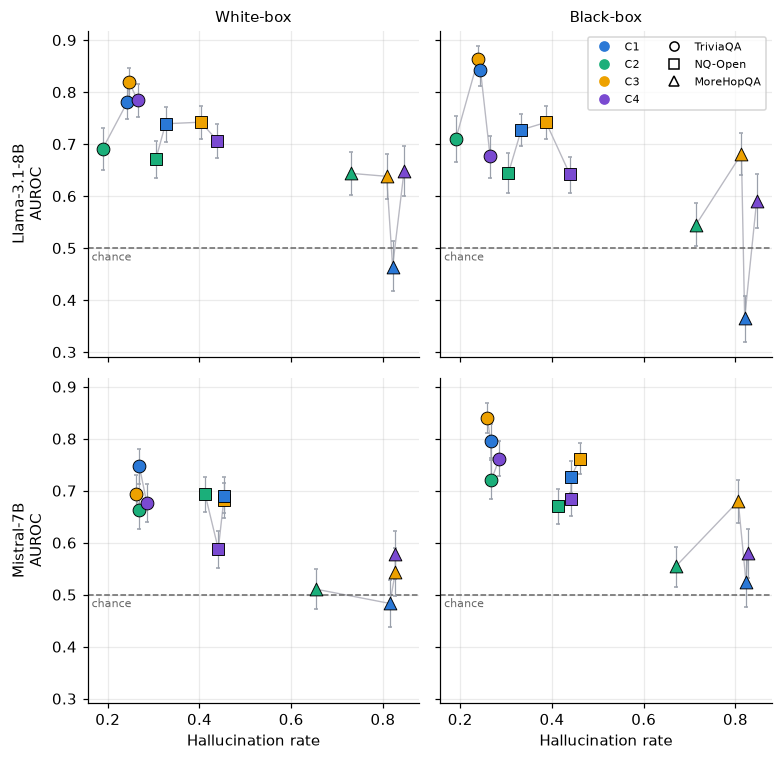

In [121]:
# Thesis version of the Section 8 scatter in result-analysis.ipynb: same content,
# but display model names, white-box first, no figure title and no correlation
# annotations (those live in hallucination_rate_vs_auroc_correlations.csv).
COND_COLORS_PLAIN = {"C1": "#2a78d6", "C2": "#1baf7a", "C3": "#eda100", "C4": "#7a4ad1"}


def plot_rate_vs_auroc_by_condition():
    with plt.rc_context({"font.size": 9.5}):
        fig, axes = plt.subplots(2, 2, figsize=(7.2, 7), sharex=True, sharey=True)
        for i, model in enumerate(FIG_MODELS):
            for j, signal in enumerate(SIGNALS):
                ax = axes[i, j]
                for dataset in FIG_DATASETS:
                    rows = [hr.loc[(model, signal, dataset, c)] for c in FIG_CONDITIONS_PLAIN]
                    pts = sorted((r["hallucination_rate"], r["auroc"], cond, r)
                                 for cond, r in zip(FIG_CONDITIONS_PLAIN, rows))
                    # Reading aid only: joins the four conditions of one dataset.
                    ax.plot([p[0] for p in pts], [p[1] for p in pts], color=TRAJECTORY_COLOR,
                            lw=0.9, zorder=1)
                    for x, y, cond, r in pts:
                        # 95% bootstrap CI on AUROC, kept visually subordinate.
                        ax.errorbar(x, y, yerr=[[y - r["auroc_ci_lo"]], [r["auroc_ci_hi"] - y]],
                                    fmt="none", ecolor=ERRORBAR_COLOR, elinewidth=0.8,
                                    capsize=1.5, zorder=2)
                        ax.scatter(x, y, marker=DATASET_MARKERS_8[dataset], s=70,
                                   color=COND_COLORS_PLAIN[cond], edgecolor="black",
                                   linewidth=0.6, zorder=3)
                ax.axhline(0.5, ls="--", lw=1, color="#666666", zorder=1)
                ax.text(0.012, 0.494, "chance", transform=ax.get_yaxis_transform(),
                        ha="left", va="top", fontsize=7, color="#666666")
                ax.grid(alpha=0.25)
                if i == 0:
                    ax.set_title(SIGNAL_LABELS[signal], fontsize=10)
                if i == len(FIG_MODELS) - 1:
                    ax.set_xlabel("Hallucination rate")
                if j == 0:
                    ax.set_ylabel(f"{model}\nAUROC")

        cond_handles = [Line2D([0], [0], marker="o", ls="none", color=COND_COLORS_PLAIN[c],
                               label=c) for c in FIG_CONDITIONS_PLAIN]
        ds_handles = [Line2D([0], [0], marker=DATASET_MARKERS_8[d], ls="none", color="none",
                             markerfacecolor="none", markeredgecolor="black",
                             label=DATASET_LABELS[d]) for d in FIG_DATASETS]
        axes[0, 1].legend(handles=cond_handles + ds_handles, fontsize=7.5, ncol=2,
                          loc="upper right")
        fig.tight_layout()

        stem = os.path.join(OUTPUT_DIR, "fig_6_10_rate_vs_auroc_by_condition")
        fig.savefig(f"{stem}.png", dpi=300, bbox_inches="tight")
        print(f"Saved -> {stem}.png  ({len(FIG_DATASETS) * len(FIG_CONDITIONS_PLAIN)} points per panel)")
        plt.show()


plot_rate_vs_auroc_by_condition()

Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/figures/fig_6_11_cost_vs_auroc.png
Saved -> /Users/fatih/Desktop/master-thesis/thesis-results/tables/cost_vs_auroc_points.csv  (48 rows)


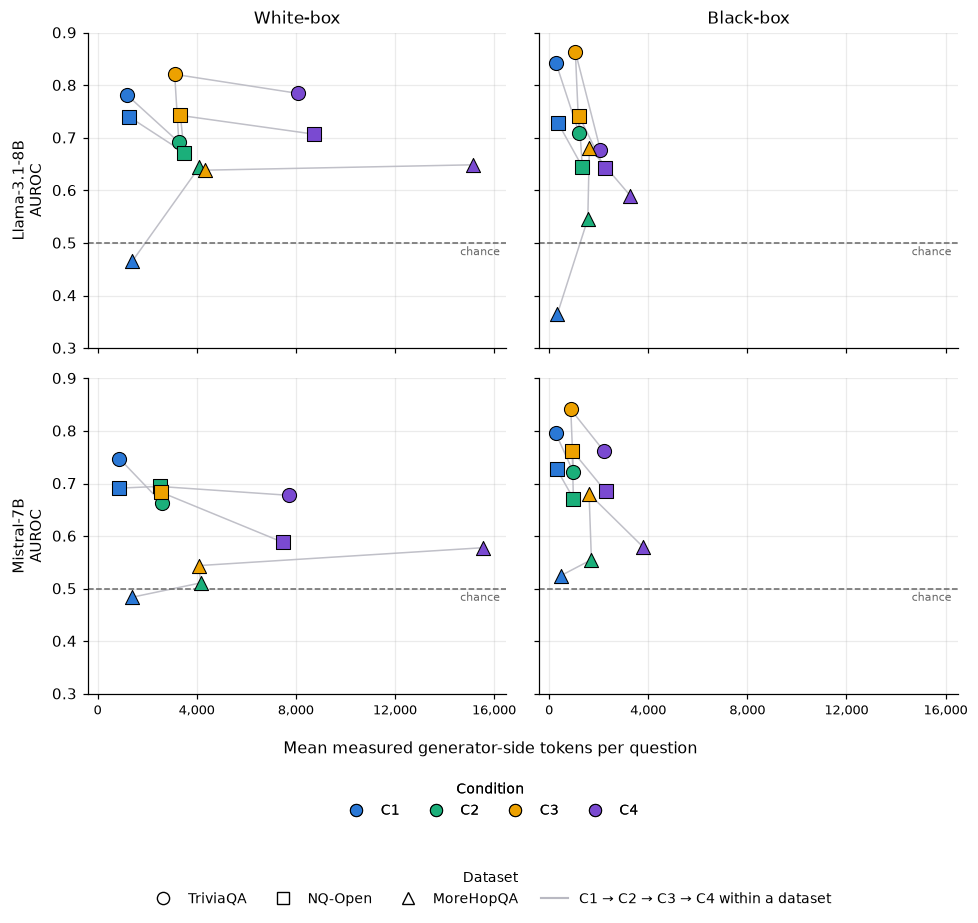

In [122]:
# Cost-performance view: measured generator-side tokens (generation + hidden-state
# forward passes) against detection quality. The NLI equivalence checks used by the
# black-box clustering are not instrumented in the logs, so they are outside this
# axis by construction - hence "measured generator-side".
#
# Condition is encoded by colour and dataset by marker shape; with 12 points per
# panel, per-point text labels collided badly, so the identification moved into
# the legend.
COST_XMAX = 16500
COST_TICKS = list(range(0, COST_XMAX + 1, 4000))


def plot_cost_vs_auroc():
    with plt.rc_context({"font.size": 9.5}):
        fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharex=True, sharey=True)
        rows_out = []
        for i, model in enumerate(FIG_MODELS):
            for j, signal in enumerate(SIGNALS):
                ax = axes[i, j]
                for dataset in FIG_DATASETS:
                    rows = [tok.loc[(model, dataset, signal, c)] for c in FIG_CONDITIONS_PLAIN]
                    xs = [r["mean_total_tokens"] for r in rows]
                    ys = [r["auroc"] for r in rows]
                    # Reading aid: the four conditions of one dataset, in order C1 -> C4.
                    ax.plot(xs, ys, "-", lw=1.0, color=TRAJECTORY_COLOR, zorder=1, alpha=0.9)
                    for cond, x, y, r in zip(FIG_CONDITIONS_PLAIN, xs, ys, rows):
                        ax.scatter(x, y, marker=DATASET_MARKERS_8[dataset], s=85,
                                   color=COND_COLORS_PLAIN[cond], edgecolor="black",
                                   linewidth=0.7, zorder=3)
                        rows_out.append({
                            "model": model, "dataset": DATASET_LABELS[dataset],
                            "signal": SIGNAL_LABELS[signal], "condition": cond,
                            "mean_gen_tokens": r["mean_gen_tokens"],
                            "mean_fwd_tokens": r["mean_fwd_tokens"],
                            "mean_total_tokens": r["mean_total_tokens"],
                            "auroc": r["auroc"],
                        })
                ax.axhline(0.5, ls="--", lw=1, color="#666666", zorder=1)
                ax.text(0.985, 0.494, "chance", transform=ax.get_yaxis_transform(),
                        ha="right", va="top", fontsize=7.5, color="#666666")
                ax.set_xlim(-400, COST_XMAX)
                ax.set_ylim(0.30, 0.90)
                ax.set_xticks(COST_TICKS)
                ax.set_xticklabels([f"{t:,}" for t in COST_TICKS], fontsize=8.5)
                ax.grid(alpha=0.25)
                if i == 0:
                    ax.set_title(SIGNAL_LABELS[signal], fontsize=11)
                if j == 0:
                    ax.set_ylabel(f"{model}\nAUROC")

        fig.supxlabel("Mean measured generator-side tokens per question", fontsize=10.5)
        cond_handles = [Line2D([0], [0], marker="o", ls="none", color=COND_COLORS_PLAIN[c],
                               markeredgecolor="black", markeredgewidth=0.7, ms=8, label=c)
                        for c in FIG_CONDITIONS_PLAIN]
        ds_handles = [Line2D([0], [0], marker=DATASET_MARKERS_8[d], ls="none", color="white",
                             markeredgecolor="black", markeredgewidth=0.9, ms=8,
                             label=DATASET_LABELS[d]) for d in FIG_DATASETS]
        ds_handles.append(Line2D([0], [0], color=TRAJECTORY_COLOR, lw=1.4,
                                 label="C1 → C2 → C3 → C4 within a dataset"))
        # Two rows rather than side by side: at this width the two legends ran into
        # each other ("C4" landing on "TriviaQA").
        leg1 = fig.legend(handles=cond_handles, title="Condition", loc="lower center",
                          bbox_to_anchor=(0.5, -0.085), ncol=4, fontsize=9, title_fontsize=9,
                          frameon=False, columnspacing=1.6)
        fig.add_artist(leg1)
        fig.legend(handles=ds_handles, title="Dataset", loc="lower center",
                   bbox_to_anchor=(0.5, -0.20), ncol=4, fontsize=9, title_fontsize=9,
                   frameon=False, columnspacing=1.6)
        fig.tight_layout()

        stem = os.path.join(OUTPUT_DIR, "fig_6_11_cost_vs_auroc")
        fig.savefig(f"{stem}.png", dpi=300, bbox_inches="tight")
        print(f"Saved -> {stem}.png")

        # The plotted points, one row per marker, so the figure can be checked
        # against a table.
        df = pd.DataFrame(rows_out)
        csv_path = os.path.join(TABLES_DIR, "cost_vs_auroc_points.csv")
        df.to_csv(csv_path, index=False, float_format="%.6f")
        print(f"Saved -> {csv_path}  ({len(df)} rows)")
        plt.show()
        return df


df_cost_auroc = plot_cost_vs_auroc()